In [1]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import joblib

In [2]:
X_train = joblib.load("../data/processed/X_train.pkl")
y_train = joblib.load("../data/processed/y_train.pkl")

X_test = joblib.load("../data/processed/X_test.pkl")
y_test = joblib.load("../data/processed/y_test.pkl")

In [9]:
# recreate feature names from original dataset (if available)
X_train = pd.DataFrame(X_train)
X_test = pd.DataFrame(X_test)

# retrain models

In [3]:
print(X_train.shape)
print(X_test.shape)

(452296, 225)
(61503, 225)


In [4]:
results = []

In [7]:
print(type(X_train))
print(type(X_test))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [5]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ),

    "LightGBM": LGBMClassifier(
        random_state=42
    )
}

In [10]:
for name, model in models.items():

    print(f"Training {name}...")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:, 1]

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc
    })

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training XGBoost...
Training LightGBM...
[LightGBM] [Info] Number of positive: 226148, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.131023 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8909
[LightGBM] [Info] Number of data points in the train set: 452296, number of used features: 217
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


In [11]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by=["Recall", "ROC-AUC"],
    ascending=False
)

results_df

,Model,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.161593,0.676737,0.260890,0.748200
5,Logistic Regression,0.161593,0.676737,0.260890,0.748200
4,LightGBM,0.169984,0.675932,0.271653,0.759091
9,LightGBM,0.169984,0.675932,0.271653,0.759091
3,XGBoost,0.173803,0.605841,0.270115,0.743985
8,XGBoost,0.173803,0.605841,0.270115,0.743985
1,Decision Tree,0.147185,0.165358,0.155743,0.540610
6,Decision Tree,0.147185,0.165358,0.155743,0.540610
2,Random Forest,0.545455,0.015710,0.030540,0.740245
7,Random Forest,0.545455,0.015710,0.030540,0.740245


In [12]:
results_df.to_csv("../reports/model_comparison.csv", index=False)

In [16]:
from lightgbm import LGBMClassifier

In [17]:
best_model = LGBMClassifier(
    random_state=42
)

best_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 226148, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.308178 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8909
[LightGBM] [Info] Number of data points in the train set: 452296, number of used features: 217
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001


In [18]:
y_pred = best_model.predict(X_test)

y_prob = best_model.predict_proba(X_test)[:, 1]

In [19]:
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[40151 16387]
 [ 1609  3356]]


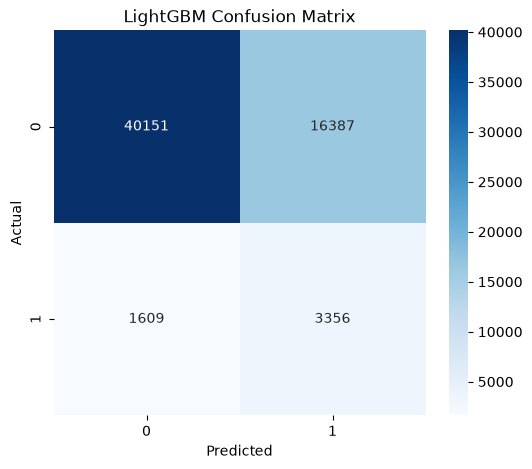

In [21]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("LightGBM Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [22]:
from sklearn.metrics import classification_report

In [23]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.96      0.71      0.82     56538
           1       0.17      0.68      0.27      4965

    accuracy                           0.71     61503
   macro avg       0.57      0.69      0.54     61503
weighted avg       0.90      0.71      0.77     61503



In [24]:
import joblib

joblib.dump(
    best_model,
    "../ml/best_model.pkl"
)

['../ml/best_model.pkl']